In [1]:
import pandas as pd
import json
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pytz
import requests
import psycopg2
import os
import pickle
os.makedirs("tmp", exist_ok=True)

In [2]:

def read_db_credentials(path="data/config.txt"):
    creds = {}
    with open(path, "r") as f:
        for line in f:
            key, value = line.strip().split("=")
            creds[key] = value
    return creds

def connect_to_db(creds):
    return psycopg2.connect(
        host=creds["host"],
        port=creds["port"],
        dbname=creds["database"],
        user=creds["user"],
        password=creds["password"]
    )


In [ ]:
cutoff =  pd.Timestamp.now().normalize()   - pd.Timedelta(days=365)
cutoff = pytz.timezone("Europe/Berlin").localize(cutoff)


def load_json_data_from_db_as_json(user = 8):
    creds = read_db_credentials()
    conn = connect_to_db(creds)

    query = f"SELECT raw_json FROM fact_raw_data WHERE data_source =health user_number = {user} ;"

    df_raw = pd.read_sql_query(query, conn)
    conn.close()

    # Parsen der JSON-Inhalte aus der 'data'-Spalte
    parsed_data = [json.loads(row['data']) for _, row in df_raw.iterrows()]

    # Rückgabe als JSON-String (optional indent für Lesbarkeit)
    return json.dumps(parsed_data, indent=2)

with open("export.json", "r") as f:  ## replace 
        health_data = json.load(f)
        
health_records = health_data["HealthData"]["Record"]


all_types = set(
    entry.get("@type")
    for entry in health_records
    if isinstance(entry, dict) and "@type" in entry
)
print(all_types)


{'HKQuantityTypeIdentifierBodyMass', 'HKQuantityTypeIdentifierActiveEnergyBurned', 'HKQuantityTypeIdentifierFlightsClimbed', 'HKQuantityTypeIdentifierStepCount', 'HKQuantityTypeIdentifierWalkingAsymmetryPercentage', 'HKQuantityTypeIdentifierWalkingSpeed', 'HKQuantityTypeIdentifierDietaryEnergyConsumed', 'HKDataTypeSleepDurationGoal', 'HKQuantityTypeIdentifierBasalEnergyBurned', 'HKQuantityTypeIdentifierDistanceWalkingRunning', 'HKQuantityTypeIdentifierWalkingDoubleSupportPercentage', 'HKQuantityTypeIdentifierHeight', 'HKQuantityTypeIdentifierDietaryWater', 'HKQuantityTypeIdentifierWalkingStepLength', 'HKCategoryTypeIdentifierSleepAnalysis', 'HKQuantityTypeIdentifierHeadphoneAudioExposure', 'HKQuantityTypeIdentifierAppleWalkingSteadiness', 'HKCategoryTypeIdentifierHeadphoneAudioExposureEvent'}


# SLEEP

In [4]:
sleep_records = [
    entry for entry in health_records
    if isinstance(entry, dict) and entry.get("@type") == "HKCategoryTypeIdentifierSleepAnalysis"
]

df_sleep = pd.DataFrame([{
    "start": pd.to_datetime(entry["@startDate"]),
    "end": pd.to_datetime(entry["@endDate"]),
    "value": entry["@value"] # Schlafphase
} for entry in sleep_records])

df_sleep = df_sleep[df_sleep["start"] >= cutoff]

df_sleep["duration_hr"] = (df_sleep["end"] - df_sleep["start"]).dt.total_seconds() / 3600
df_sleep["date"] = df_sleep["start"].dt.date
display(df_sleep)
sleep_per_night = df_sleep.groupby("date")["duration_hr"].sum().reset_index()
awakenings_per_night = df_sleep.groupby("date").size().reset_index(name="phases")
sleep_summary = pd.merge(sleep_per_night, awakenings_per_night, on="date")
sleep_summary.columns = ["date", "total_sleep_hr", "sleep_phases"]

print(sleep_summary)

,start,end,value,duration_hr,date
3725,2024-06-24 00:26:40+02:00,2024-06-24 00:28:20+02:00,HKCategoryValueSleepAnalysisInBed,0.027778,2024-06-24
3726,2024-06-24 00:41:55+02:00,2024-06-24 00:43:41+02:00,HKCategoryValueSleepAnalysisInBed,0.029444,2024-06-24
3727,2024-06-24 00:43:57+02:00,2024-06-24 07:50:00+02:00,HKCategoryValueSleepAnalysisInBed,7.100833,2024-06-24
3728,2024-06-25 00:19:34+02:00,2024-06-25 04:23:15+02:00,HKCategoryValueSleepAnalysisInBed,4.061389,2024-06-25
3729,2024-06-25 04:23:30+02:00,2024-06-25 06:43:12+02:00,HKCategoryValueSleepAnalysisInBed,2.328333,2024-06-25
...,...,...,...,...,...
5123,2024-11-23 11:03:34+02:00,2024-11-23 11:31:06+02:00,HKCategoryValueSleepAnalysisInBed,0.458889,2024-11-23
5124,2024-11-23 11:46:36+02:00,2024-11-23 11:47:44+02:00,HKCategoryValueSleepAnalysisInBed,0.018889,2024-11-23
5125,2024-11-23 11:48:15+02:00,2024-11-23 11:48:20+02:00,HKCategoryValueSleepAnalysisInBed,0.001389,2024-11-23
5126,2024-11-23 11:49:13+02:00,2024-11-23 12:02:15+02:00,HKCategoryValueSleepAnalysisInBed,0.217222,2024-11-23


           date  total_sleep_hr  sleep_phases
0    2024-06-24        7.158056             3
1    2024-06-25        7.418889            11
2    2024-06-26        7.224167             6
3    2024-06-27        6.728056            11
4    2024-06-28        7.236389             2
..          ...             ...           ...
146  2024-11-19        6.670556            15
147  2024-11-20        6.940278             4
148  2024-11-21        6.445833            10
149  2024-11-22        6.913611            10
150  2024-11-23        8.185278            19

[151 rows x 3 columns]


In [5]:
def classify_cat_by_sleep(hours):
    """
    Klassifiziere eine Katze basierend auf ihrer durchschnittlichen Schlafdauer pro Tag.
    
    Parameter:
        hours (float): Anzahl der Schlafstunden pro Tag.
        
    Rückgabe:
        str: Kategorie ("Long sleeper", "optimal sleeper", "slightly short", "Sleep deprived")
    """
    if hours > 9:
        return "Long sleeper"
    elif hours >= 7:
        return "optimal sleeper"
    elif hours >= 6:
        return "slightly short"
    else:
        return "Sleep deprived"


# STEPS

In [6]:

step_records = [
    entry for entry in health_records
    if isinstance(entry, dict) and entry.get("@type") == "HKQuantityTypeIdentifierStepCount"
]

df_steps= pd.DataFrame([{
    "startDate": pd.to_datetime(entry["@startDate"]),
    "endDate": pd.to_datetime(entry["@endDate"]),
    "value": entry["@value"] # Schlafphase
} for entry in step_records])

df_steps = df_steps[df_steps["startDate"] >= cutoff]

daily_steps  = df_steps    # Optional: Umwandlung in passende Datentypen
daily_steps["startDate"] = pd.to_datetime(daily_steps ["startDate"])
daily_steps["endDate"] = pd.to_datetime(daily_steps ["endDate"])
daily_steps["value"] = pd.to_numeric(daily_steps ["value"])
 


daily_steps["date"] = pd.to_datetime(daily_steps["startDate"]).dt.date
daily_steps = daily_steps.groupby("date")["value"].sum().reset_index()

# Optional: Spalte umbenennen für Lesbarkeit
daily_steps.columns = ["date", "total_steps"]

print(daily_steps.head())
# Neuberechnung der Dauer in Minuten und Schritttempo



         date  total_steps
0  2024-06-24         8077
1  2024-06-25         7803
2  2024-06-26         4773
3  2024-06-27         8003
4  2024-06-28        13430


In [7]:
def classify_cat_by_steps(avg_steps):
    """
    Klassifiziere eine Katze basierend auf ihrer durchschnittlichen Schrittanzahl pro Tag.
    
    Parameter:
        avg_steps (int or float): Durchschnittliche Anzahl an Schritten pro Tag.
        
    Rückgabe:
        str: Kategorie ("Active walker", "typical", "Sedentary")
    """
    if avg_steps >= 10000:
        return "Active walker"
    elif avg_steps >= 3000:
        return "typical"
    else:
        return "Sedentary"


# ACTIVITY TIME

In [8]:
cutoff_hours = [0, 4, 8, 12, 16, 20]

def split_sleep_period(row):
    splits = []
    start = row["start"]
    end = row["end"]
    
    current = start
    while current < end:
        next_cutoffs = [
            current.replace(hour=h, minute=0, second=0, microsecond=0)
            + timedelta(days=(1 if h <= current.hour else 0))
            for h in cutoff_hours
        ]
        next_boundary = min([t for t in next_cutoffs if t > current] + [end, current + timedelta(hours=4)])
        segment_end = min(next_boundary, current + timedelta(hours=4), end)
        
        splits.append({
            "start": current,
            "end": segment_end,
            "duration_hr": (segment_end - current).total_seconds() / 3600
        })
        current = segment_end
    
    return splits

# Anwenden
expanded_rows = []
for _, row in df_sleep.iterrows():
    expanded_rows.extend(split_sleep_period(row))

expanded_df = pd.DataFrame(expanded_rows)
print(expanded_df)
df_sleep = expanded_df

                         start                       end  duration_hr
0    2024-06-24 00:26:40+02:00 2024-06-24 00:28:20+02:00     0.027778
1    2024-06-24 00:41:55+02:00 2024-06-24 00:43:41+02:00     0.029444
2    2024-06-24 00:43:57+02:00 2024-06-24 04:00:00+02:00     3.267500
3    2024-06-24 04:00:00+02:00 2024-06-24 07:50:00+02:00     3.833333
4    2024-06-25 00:19:34+02:00 2024-06-25 04:00:00+02:00     3.673889
...                        ...                       ...          ...
1635 2024-11-23 11:46:36+02:00 2024-11-23 11:47:44+02:00     0.018889
1636 2024-11-23 11:48:15+02:00 2024-11-23 11:48:20+02:00     0.001389
1637 2024-11-23 11:49:13+02:00 2024-11-23 12:00:00+02:00     0.179722
1638 2024-11-23 12:00:00+02:00 2024-11-23 12:02:15+02:00     0.037500
1639 2024-11-23 12:03:42+02:00 2024-11-23 12:04:17+02:00     0.009722

[1640 rows x 3 columns]


In [9]:

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daypart_order = ["Night", "Early Morning", "Morning", "Noon", "Afternoon", "Evening"]

df_dtactivity =df_steps 
df_sleeptime = df_sleep

df_dtactivity["startDate"] = pd.to_datetime(df_dtactivity["startDate"])
df_sleeptime["startDate"] = pd.to_datetime(df_sleeptime["start"])

# 1. Wochentag extrahieren (z. B. "Montag")
df_dtactivity["weekday"] = df_dtactivity["startDate"].dt.day_name(locale="en_GB")  # für deutschsprachige Ausgabe
df_sleeptime["weekday"] = df_sleeptime["startDate"].dt.day_name(locale="en_GB")  # für deutschsprachige Ausgabe

# 2. Tageszeit-Kategorie erstellen
def get_day_part(hour):
    if 0 <= hour < 4:
        return "Night"
    elif 6 <= hour < 8:
        return "Early Morning"
    elif 8 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 16:
        return  "Noon"
    elif 16 <= hour < 20:
        return "Afternoon"
    else:
        return "Evening"

df_dtactivity["day_part"] = df_dtactivity["startDate"].dt.hour.apply(get_day_part)
df_sleeptime["day_part"] = df_sleeptime["startDate"].dt.hour.apply(get_day_part)
# 3. Gruppieren nach Wochentag & Tageszeit, dann durchschnittliche Schritte berechnen

df_dtactivity["date"] = df_dtactivity["startDate"].dt.date
df_sleeptime["date"] = df_sleeptime["startDate"].dt.date
# print(df_sleeptime)

df_dtactivity = df_dtactivity.groupby(["date","weekday", "day_part"])["value"].sum().reset_index()
df_dtactivity = df_dtactivity.groupby(["weekday", "day_part"])["value"].mean().reset_index()

df_sleeptime= df_sleeptime.groupby(["date","weekday", "day_part"])["duration_hr"].sum().reset_index()
df_sleeptime = df_sleeptime.groupby(["weekday", "day_part"])["duration_hr"].mean().reset_index()

# 4. Umbenennen
df_dtactivity.columns = ["weekday", "day_part", "steps"]
df_sleeptime.columns = ["weekday", "day_part", "sleep_hours"]

# Optional: Wochentag sortieren (Montag zuerst)

df_dtactivity["weekday"] = pd.Categorical(df_dtactivity["weekday"], categories=weekday_order, ordered=True)
df_dtactivity["day_part"] = pd.Categorical(df_dtactivity["day_part"], categories=daypart_order, ordered=True)

df_sleeptime["weekday"] = pd.Categorical(df_sleeptime["weekday"], categories=weekday_order, ordered=True)
df_sleeptime["day_part"] = pd.Categorical(df_sleeptime["day_part"], categories=daypart_order, ordered=True)

# Sortieren
df_sleeptime = df_sleeptime.sort_values(["weekday", "day_part"]).reset_index(drop=True)
# Ergebnis anzeigen


# Neue englische + zeitspezifische Labels
daypart_labels = {
    "Night": "Night\n(0–4)",
    "Early Morning": "Early Morning\n(4–8)",
    "Morning": "Morning\n(8–12)",
    "Noon": "Noon\n(12–16)",
    "Afternoon": "Afternoon\n(16–20)",
    "Evening": "Evening\n(20–24)"
}

df_dtactivity = df_dtactivity.merge(df_sleeptime, how = "left")
df_dtactivity["sleep_hours"] = df_dtactivity["sleep_hours"].fillna(0)
# Wenn nötig, erst umbenennen
df_dtactivity["day_part"] = df_dtactivity["day_part"].cat.rename_categories(daypart_labels)


# Kategorische Sortierung (für Ordnung in Achsen)
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daypart_order = list(daypart_labels.values())

df_dtactivity["weekday"] = pd.Categorical(df_dtactivity["weekday"], categories=weekday_order, ordered=True)
df_dtactivity["day_part"] = pd.Categorical(df_dtactivity["day_part"], categories=daypart_order, ordered=True)
import numpy as np

df_dtactivity["workload_score"] = (
    (1 - np.tanh(df_dtactivity["steps"] / 1500)) * 0.4 +
    (1 - df_dtactivity["sleep_hours"] / 4) * 0.6
)
df_dtactivity["workload_score"] = df_dtactivity["workload_score"].clip(lower=0, upper=1)
df_dtactivity= df_dtactivity.sort_values(["weekday","day_part"]).reset_index()
display(df_dtactivity.sort_values(["weekday","day_part"]))


,index,weekday,day_part,steps,sleep_hours,workload_score
0,10,Monday,Night\n(0–4),315.516129,3.386477,0.409110
1,7,Monday,Early Morning\n(4–8),424.181818,0.921111,0.751640
2,9,Monday,Morning\n(8–12),1138.714286,0.827569,0.619636
3,11,Monday,Noon\n(12–16),1617.769231,0.000000,0.682941
4,6,Monday,Afternoon\n(16–20),2868.423077,0.000000,0.617089
5,8,Monday,Evening\n(20–24),2484.730769,3.347033,0.126048
6,34,Tuesday,Night\n(0–4),951.428571,3.221414,0.292389
7,31,Tuesday,Early Morning\n(4–8),1455.368421,0.632262,0.605636
8,33,Tuesday,Morning\n(8–12),1290.153846,0.828056,0.597267
9,35,Tuesday,Noon\n(12–16),1695.764706,0.000000,0.675523


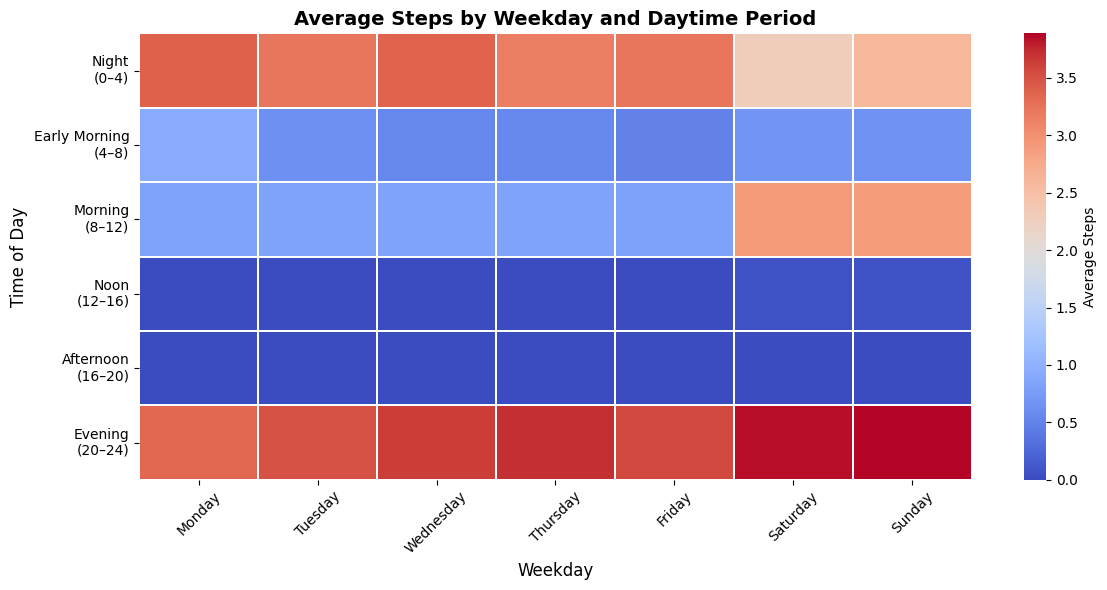

In [10]:

# Heatmap-Daten vorbereiten
heatmap_data = df_dtactivity.pivot(index="day_part", columns="weekday", values="sleep_hours")

# Heatmap zeichnen
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    annot=False,
    cbar_kws={'label': 'Average Steps'},
    linewidths=0.3,
    linecolor='white'
)
plt.title("Average Steps by Weekday and Daytime Period", fontsize=14, weight='bold')
plt.xlabel("Weekday", fontsize=12)
plt.ylabel("Time of Day", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()




# WALKS

In [11]:

df_walks = df_steps
df_walks = df_walks.sort_values("startDate").reset_index(drop=True)

clusters = []
current_cluster = [df_walks.iloc[0]]

for i in range(1, len(df_walks)):
    previous = current_cluster[-1]
    current = df_walks.iloc[i]
    
    time_gap = (current["startDate"] - previous["endDate"])
    
    if time_gap <= timedelta(minutes=5):
        current_cluster.append(current)
    else:
        clusters.append(current_cluster)
        current_cluster = [current]

# letzte Gruppe nicht vergessen
clusters.append(current_cluster)

# Aggregation
aggregated = []

for group in clusters:
    group_df = pd.DataFrame(group)
    start = group_df["startDate"].min()
    end = group_df["endDate"].max()
    total_steps = group_df["value"].sum()
    duration_min = (end - start).total_seconds() / 60
    km = total_steps * 0.762 / 1000
    speed_kmh = km / (duration_min / 60) if duration_min > 0 else 0

    aggregated.append({
        "start": start,
        "end": end,
        "steps": total_steps,
        "duration_min": duration_min,
        "estimated_km": km,
        "estimated_speed_kmh": speed_kmh
    })

# In DataFrame umwandeln
df_agg = pd.DataFrame(aggregated)

# Spaziergänge filtern: Dauer 20–90 Min, Geschwindigkeit 2–5 km/h
df_agg["vermutlich_spaziergang"] = df_agg["duration_min"].between(20, 120) & df_agg["estimated_speed_kmh"].between(2,7.5 )& (df_agg["estimated_km"] > 3)

# Ausgabe
df_walks = df_agg[df_agg["vermutlich_spaziergang"]].copy()

# Neue Spalten anlegen und umbenennen
df_walks["activity"] = "Walk"
df_walks["timestamp"] = df_walks["start"]
df_walks["duration"] = df_walks["duration_min"]
df_walks["distance"] = df_walks["estimated_km"]
df_walks["type"] = "Wellness"

# Nur relevante Spalten
df_walks= df_walks[["activity", "timestamp", "duration", "distance", "type"]]

# Optional: auf sinnvolle Nachkommastellen runden
df_walks["duration"] = df_walks["duration"].round(2)
df_walks["distance"] = df_walks["distance"].round(3)


# DataFrame als Pickle-Datei speichern
with open("tmp/activites.pkl", "wb") as f:
    pickle.dump(df_walks, f)



# WELLNESS SCORE

In [12]:

from statistics import mean
import pandas as pd

def calculate_wellness_score(health_records, sleep_summary):
    # --- Bewegung ---
    step_records = [
        e for e in health_records if e.get("@type") == "HKQuantityTypeIdentifierStepCount"
    ]
    distance_records = [
        e for e in health_records if e.get("@type") == "HKQuantityTypeIdentifierDistanceWalkingRunning"
    ]
    steps = sum(float(e.get("value", 0)) for e in step_records)
    distance_km = sum(float(e.get("value", 0)) for e in distance_records) / 1000  # Meter → km

    movement_score = min((steps / 7000 + distance_km / 5 ) / 2, 1)

    # --- Schlaf ---
    def compute_nightly_sleep_score(row):
        sleep = row["total_sleep_hr"]
        wakeups = row["sleep_phases"]

        # Basis-Schlafscore
        if sleep >= 7:
            score = 1
        elif sleep >= 6.5:
            score = 0.8
        elif sleep >= 6:
            score = 0.6
        elif sleep >= 5.5:
            score = 0.4
        elif sleep >= 5:
            score = 0.2
        else:
            score = 0

        # Strafe für viele Aufwachphasen
        if wakeups > 10:
            penalty = min((wakeups - 10) * 0.05, 0.3)
            score = max(0, score - penalty)

        return score

    # Score pro Nacht berechnen
    sleep_summary["sleep_score"] = sleep_summary.apply(compute_nightly_sleep_score, axis=1)

    # Durchschnittlicher Schlafscore über alle Nächte
    sleep_score = sleep_summary["sleep_score"].mean()


    # --- Ernährung ---
    water_values = [float(e.get("value", 0)) for e in health_records if e.get("@type") == "HKQuantityTypeIdentifierDietaryWater"]
    kcal_values = [float(e.get("value", 0)) for e in health_records if e.get("@type") == "HKQuantityTypeIdentifierDietaryEnergyConsumed"]

    if not water_values or not kcal_values or sum(water_values) == 0 or sum(kcal_values) == 0:
        print("⚠️  Warnung: Keine brauchbaren Ernährungsdaten (Wasser oder Kalorien) vorhanden oder Werte sind alle 0.")
        nutrition_score = None  # oder z. B. 0.5 als Fallback
    else:
        water = sum(water_values) / 1000  # ml → Liter
        kcal = sum(kcal_values)
        kcal_score = 1 if 2000 <= kcal <= 2500 else 0.5
        nutrition_score = min((water / 2 + kcal_score) / 2, 1)



    # --- BMI ---
    weight_entry = next((e for e in health_records if e.get("@type") == "HKQuantityTypeIdentifierBodyMass"), None)
    height_entry = next((e for e in health_records if e.get("@type") == "HKQuantityTypeIdentifierHeight"), None)
    
    sex_entry = next((e for e in health_records if e.get("@type") == "HKBiologicalSex"), {})
    sex = str(sex_entry.get("value", "")).lower()
    default_height = 178 if sex == "male" else 165 if sex == "female" else 170

    if weight_entry:
        weight = float(weight_entry.get("value", 0))
        if height_entry:
            height = float(height_entry.get("value", 0))
        else:
            height = default_height  # fallback auf Durchschnittsgröße

        if height <= 0:
            print("Warnung: Ungültige Körpergröße für BMI:", height)
            bmi_score = 0.5
        else:
            bmi = weight / (height / 100) ** 2
            bmi_score = 1 if 18.5 <= bmi <= 25 else 0.5 if 25 < bmi <= 30 else 0.2
    else:
        bmi_score = 0.5

    # --- Stress / Belastung ---
    audio_exposure = sum(float(e.get("value", 0)) for e in health_records if e.get("@type") == "HKQuantityTypeIdentifierHeadphoneAudioExposure")
    stress_score = max(0, 1 - (audio_exposure / 100))

    # --- Mobilität ---
    walking_speed = next((float(e.get("value", 0)) for e in health_records if e.get("@type") == "HKQuantityTypeIdentifierWalkingSpeed"), 0)
    steadiness = next((float(e.get("value", 50)) for e in health_records if e.get("@type") == "HKQuantityTypeIdentifierAppleWalkingSteadiness"), 50)
    mobility_score = min((walking_speed / 1.2 + steadiness / 100) / 2, 1)

    # --- Gewichtung und finaler Score ---
    scores = {
        "movement_score": [movement_score, 0.2],
        "sleep_score": [sleep_score, 0.2],
        "nutrition_score": [nutrition_score, 0.15],
        "bmi_score": [bmi_score, 0.15],
        "stress_score": [stress_score, 0.2],
        "mobility_score": [mobility_score, 0.1],
    }

    df_scores = pd.DataFrame.from_dict(scores, orient='index', columns=["score", "weight"])
        # NaN bei score → Gewicht auf 0 setzen
    df_scores.loc[df_scores["score"].isna(), "weight"] = 0

    # Gewichte neu skalieren auf 1.0 (damit Summe wieder 100% ergibt)
    total_weight = df_scores["weight"].sum()
    df_scores["weight"] = df_scores["weight"] / total_weight
    df_scores["weighted_score"] = df_scores["score"] * df_scores["weight"]
    df_scores.loc["total"] = ["", "", round(df_scores["weighted_score"].sum(), 2)]


    return df_scores

calculate_wellness_score(health_records,sleep_summary)


⚠️  Warnung: Keine brauchbaren Ernährungsdaten (Wasser oder Kalorien) vorhanden oder Werte sind alle 0.
Warnung: Ungültige Körpergröße für BMI: 0.0


,score,weight,weighted_score
movement_score,0.0,0.235294,0.000000
sleep_score,0.787748,0.235294,0.185353
nutrition_score,NaN,0.0,NaN
bmi_score,0.5,0.176471,0.088235
stress_score,1.0,0.235294,0.235294
mobility_score,0.25,0.117647,0.029412
total,,,0.540000


In [13]:
def get_next_at_id(conn):
    with conn.cursor() as cur:
        cur.execute("SELECT MAX(at_id) FROM dim_activity_times;")
        result = cur.fetchone()
        max_id = result[0] if result[0] is not None else 0
        return max_id + 1



In [14]:
print(sleep_summary.head())


         date  total_sleep_hr  sleep_phases  sleep_score
0  2024-06-24        7.158056             3         1.00
1  2024-06-25        7.418889            11         0.95
2  2024-06-26        7.224167             6         1.00
3  2024-06-27        6.728056            11         0.75
4  2024-06-28        7.236389             2         1.00


In [ ]:
creds = read_db_credentials()
conn = connect_to_db(creds)

user_number = 9999
at_id = get_next_at_id(conn)
# Werte direkt beim Berechnen formatieren (4 Nachkommastellen, float)
steps_avg = round(float(daily_steps["total_steps"].mean()), 4)
sleep_hours_avg = round(float(sleep_summary["total_sleep_hr"].mean()), 4)
sleep_hours_std = round(float(sleep_summary["total_sleep_hr"].std()), 4)
sleep_wakeups_avg = round(float(sleep_summary["sleep_phases"].sub(1).mean()), 4)
sleep_hours_goal = 7.0000  # Festwert, direkt im Format
tot_wellness_score = round(float(calculate_wellness_score(health_records, sleep_summary).loc["total", "weighted_score"]), 4)

# Kategorien (bleiben Strings)
type_walker = classify_cat_by_steps(steps_avg)
type_sleeper = classify_cat_by_sleep(sleep_hours_avg)

cur = conn.cursor()

# SQL-INSERT-Statement
insert_sql = """
INSERT INTO dim_health (
    at_id,
    user_number,
    steps_avg,
    sleep_hours_avg,
    sleep_hours_std,
    sleep_wakeups_avg,
    sleep_hours_goal,
    tot_wellness_score,
    type_walker,
    type_sleeper
) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s);
"""

# Werte vorbereiten
values = (
    at_id,
    user_number,
    steps_avg,
    sleep_hours_avg,
    sleep_hours_std,
    sleep_wakeups_avg,
    sleep_hours_goal,
    tot_wellness_score,
    type_walker,
    type_sleeper
)

clean_values = tuple(
    round(v, 4) if isinstance(v, (np.float64, float)) else v
    for v in values
)


cur.execute(insert_sql, clean_values)

conn.commit()

print("Daten erfolgreich eingefügt.")


⚠️  Warnung: Keine brauchbaren Ernährungsdaten (Wasser oder Kalorien) vorhanden oder Werte sind alle 0.
Warnung: Ungültige Körpergröße für BMI: 0.0
Daten erfolgreich eingefügt.


In [18]:

def save_df_to_db(df, table_name):
    creds = read_db_credentials()
    conn = connect_to_db(creds)
    cursor = conn.cursor()
    
    df = df.where(pd.notnull(df), None)  # NaN → None
    
    columns = ', '.join(df.columns)
    placeholders = ', '.join(['%s'] * len(df.columns))
    
    insert_query = f"""
        INSERT INTO {table_name} ({columns})
        VALUES ({placeholders})
    """
    
    for _, row in df.iterrows():
        for i, val in enumerate(row.tolist()):
            print(f"{df.columns[i]} -> {val} ({type(val)})")

        cursor.execute(insert_query, row.tolist())


    conn.commit()
    cursor.close()
    conn.close()


df_dtactivity["at_id"] = get_next_at_id(conn)
print(df_dtactivity)
df_dtactivity.drop(columns=["index"], inplace=True)


    index    weekday              day_part        steps  sleep_hours  \
0      10     Monday          Night\n(0–4)   315.516129     3.386477   
1       7     Monday  Early Morning\n(4–8)   424.181818     0.921111   
2       9     Monday       Morning\n(8–12)  1138.714286     0.827569   
3      11     Monday         Noon\n(12–16)  1617.769231     0.000000   
4       6     Monday    Afternoon\n(16–20)  2868.423077     0.000000   
5       8     Monday      Evening\n(20–24)  2484.730769     3.347033   
6      34    Tuesday          Night\n(0–4)   951.428571     3.221414   
7      31    Tuesday  Early Morning\n(4–8)  1455.368421     0.632262   
8      33    Tuesday       Morning\n(8–12)  1290.153846     0.828056   
9      35    Tuesday         Noon\n(12–16)  1695.764706     0.000000   
10     30    Tuesday    Afternoon\n(16–20)  1952.941176     0.000000   
11     32    Tuesday      Evening\n(20–24)  2493.700000     3.494563   
12     40  Wednesday          Night\n(0–4)  1118.423077     3.38

In [ ]:

save_df_to_db(df_dtactivity,"dim_activity_times")





import psycopg2

weekday -> Monday (<class 'str'>)
day_part -> Night
(0–4) (<class 'str'>)
steps -> 315.51612903225805 (<class 'float'>)
sleep_hours -> 3.3864772727272725 (<class 'float'>)
workload_score -> 0.40911007976480307 (<class 'float'>)
at_id -> 1 (<class 'int'>)
weekday -> Monday (<class 'str'>)
day_part -> Early Morning
(4–8) (<class 'str'>)
steps -> 424.1818181818182 (<class 'float'>)
sleep_hours -> 0.9211111111111111 (<class 'float'>)
workload_score -> 0.7516399902566697 (<class 'float'>)
at_id -> 1 (<class 'int'>)
weekday -> Monday (<class 'str'>)
day_part -> Morning
(8–12) (<class 'str'>)
steps -> 1138.7142857142858 (<class 'float'>)
sleep_hours -> 0.8275694444444445 (<class 'float'>)
workload_score -> 0.6196358596683943 (<class 'float'>)
at_id -> 1 (<class 'int'>)
weekday -> Monday (<class 'str'>)
day_part -> Noon
(12–16) (<class 'str'>)
steps -> 1617.7692307692307 (<class 'float'>)
sleep_hours -> 0.0 (<class 'float'>)
workload_score -> 0.6829412209329501 (<class 'float'>)
at_id -> 1 (<c